<h3>เป้าหมายที่ 4: สร้างหลักประกันว่าทุกคนมีการศึกษาที่มีคุณภาพอย่างครอบคลุมและเท่าเทียม และสนับสนุนโอกาสในการเรียนรู้ตลอดชีวิต </h3>

<h3>เป้าหมายที่ 10: ลดความไม่เสมอภาคภายในและระหว่างประเทศ</h3>

In [ ]:
import torch
p = torch.cuda.get_device_properties(0)
print(p.name, p.major, p.minor)  # major=8, minor=7  -> 8.7


In [ ]:
import mediapipe as mp, sys
print("mediapipe    :", mp.__version__)
# ไม่มี API ทางการบอก CUDA ตรงๆ ใน Python
# ทดสอบว่า Tasks delegate=GPU ใช้ได้ไหม (ส่วนใหญ่บน Jetson จะไม่รองรับ → error/fallback)
try:
    from mediapipe.tasks.python import BaseOptions
    print("Tasks module available. GPU delegate on Jetson is generally unsupported.")
except Exception as e:
    print("Tasks module not available or import error:", e)
print("Conclusion: MediaPipe pip wheel on Jetson = CPU-only (unless you custom-build).")


In [1]:
import cv2
import numpy as np
import os
from matplotlib import pyplot as plt
import time
import mediapipe as mp



2025-10-15 22:20:11.031379: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-15 22:20:11.116918: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1760541611.161355  171895 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1760541611.172858  171895 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1760541611.238399  171895 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [2]:
import sys, cv2
print("python =", sys.executable)
print("cv2   =", cv2.__file__)



python = /home/mercuone145/projects/TSL217/venv/bin/python
cv2   = /home/mercuone145/projects/TSL217/venv/lib/python3.12/site-packages/cv2/__init__.py


<h2>Keypoint MP Holistic</h2>

In [2]:
mp_holistic = mp.solutions.holistic
mp_drawing = mp.solutions.drawing_utils
mp_face_mesh = mp.solutions.face_mesh

In [3]:
def mediapipe_detection(image, model):
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # COLOR CONVERSION BGR 2 RGB
    image.flags.writeable = False                  # Image is no longer writeable
    results = model.process(image)                 # Make prediction
    image.flags.writeable = True                   # Image is now writeable 
    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR) # COLOR COVERSION RGB 2 BGR
    return image, results

In [4]:
def draw_landmarks(image, results):
    # Face landmarks
    # if results.face_landmarks:
    #     mp_drawing.draw_landmarks(
    #         image, 
    #         results.face_landmarks, 
    #         mp_face_mesh.FACEMESH_CONTOURS  # แก้ไขเป็น FACEMESH_CONTOURS
    #     )

    # Pose landmarks
    if results.pose_landmarks:
        mp_drawing.draw_landmarks(
            image, 
            results.pose_landmarks, 
            mp_holistic.POSE_CONNECTIONS
        )
    
    # Left hand landmarks
    if results.left_hand_landmarks:
        mp_drawing.draw_landmarks(
            image, 
            results.left_hand_landmarks, 
            mp_holistic.HAND_CONNECTIONS
        )

    # Right hand landmarks
    if results.right_hand_landmarks:
        mp_drawing.draw_landmarks(
            image, 
            results.right_hand_landmarks, 
            mp_holistic.HAND_CONNECTIONS
        )


In [5]:
def draw_styled_landmarks(image, results):
    # mp_drawing.draw_landmarks(
    #         image, 
    #         results.face_landmarks, 
    #         mp_face_mesh.FACEMESH_CONTOURS ,
    #         mp_drawing.DrawingSpec(color=(80,110,10), thickness=1, circle_radius=1),
    #         mp_drawing.DrawingSpec(color=(80,256,121), thickness=1, circle_radius=1)
    #     )
    
    mp_drawing.draw_landmarks(
            image, 
            results.pose_landmarks, 
            mp_holistic.POSE_CONNECTIONS,
            mp_drawing.DrawingSpec(color=(80,22,10), thickness=1, circle_radius=1),
            mp_drawing.DrawingSpec(color=(80,44,121), thickness=1, circle_radius=1)
            
        )
    
    mp_drawing.draw_landmarks(
            image, 
            results.left_hand_landmarks, 
            mp_holistic.HAND_CONNECTIONS,
            mp_drawing.DrawingSpec(color=(121,22,76), thickness=1, circle_radius=1),
            mp_drawing.DrawingSpec(color=(121,44,250), thickness=1, circle_radius=1)
        )
    
    mp_drawing.draw_landmarks(
            image, 
            results.right_hand_landmarks, 
            mp_holistic.HAND_CONNECTIONS,
            mp_drawing.DrawingSpec(color=(245,117,66), thickness=1, circle_radius=1),
            mp_drawing.DrawingSpec(color=(245,66,2330), thickness=1, circle_radius=1)
        )

In [ ]:
import cv2
import time

# เปิดกล้อง (0 = กล้องตัวแรก)
cap = cv2.VideoCapture(0)
cap.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 360)

prev_time = 0   # สำหรับคำนวณ FPS

with mp_holistic.Holistic(min_detection_confidence=0.75,
                          min_tracking_confidence=0.75) as holistic:
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        h, w = frame.shape[:2]
        one_seventh = w // 6          # แบ่งจอเป็น 7 ส่วน
        x1, x2 = one_seventh * 1, one_seventh * 5   # ใช้ช่วง 2–5 (≈ 28%–71%)

        # --- ROI เฉพาะกลางจอ (ช่วง 2–5) ---
        roi = frame[:, x1:x2]
        roi_img, results = mediapipe_detection(roi, holistic)
        draw_styled_landmarks(roi_img, results)

        # วาง ROI กลับเข้าเฟรมเต็ม
        frame[:, x1:x2] = roi_img

        # คำนวณ FPS
        current_time = time.time()
        fps = 1 / (current_time - prev_time) if prev_time != 0 else 0
        prev_time = current_time

        # แสดง FPS บนเฟรม
        cv2.putText(frame, f'FPS: {int(fps)}', (10, 30),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

        # เส้นกรอบช่วยบอกขอบเขตตรวจจับ
        cv2.rectangle(frame, (x1, 0), (x2-1, h-1), (0, 255, 255), 2)

        cv2.imshow('OpenCV Feed', frame)

        if cv2.waitKey(10) & 0xFF == ord('q'):
            break

cap.release()
cv2.destroyAllWindows()


In [ ]:

cap = cv2.VideoCapture(0)
cap.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 360)

prev_time = 0
mp_holistic = mp.solutions.holistic

with mp_holistic.Holistic(min_detection_confidence=0.5,
                          min_tracking_confidence=0.5) as holistic:

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        # ประมวลผลด้วย mediapipe
        image, results = mediapipe_detection(frame, holistic)
        draw_styled_landmarks(frame, results)

        # คำนวณ FPS
        curr_time = time.time()
        fps = 0 if prev_time == 0 else 1 / (curr_time - prev_time)
        prev_time = curr_time

        # วางข้อความ FPS ที่มุมขวาบน
        h, w = frame.shape[:2]
        cv2.putText(frame, f'FPS: {int(fps)}',
                    (w - 150, 30),                      # ➡ ตำแหน่ง x,y
                    cv2.FONT_HERSHEY_SIMPLEX, 1,        # ➡ ฟอนต์และขนาด
                    (0, 255, 0), 2)                     # ➡ สีเขียว ขนาดเส้น 2

        # แสดงผลภาพ
        cv2.imshow('OpenCV Feed', frame)

        # ออกจากลูปเมื่อกด q
        if cv2.waitKey(10) & 0xFF == ord('q'):
            break
cap = cv2.VideoCapture(0)
cap.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 360)

prev_time = 0
mp_holistic = mp.solutions.holistic

with mp_holistic.Holistic(min_detection_confidence=0.75,
                          min_tracking_confidence=0.75) as holistic:

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        # ประมวลผลด้วย mediapipe
        image, results = mediapipe_detection(frame, holistic)
        draw_styled_landmarks(frame, results)

        # คำนวณ FPS
        curr_time = time.time()
        fps = 0 if prev_time == 0 else 1 / (curr_time - prev_time)
        prev_time = curr_time

        # วางข้อความ FPS ที่มุมขวาบน
        h, w = frame.shape[:2]
        cv2.putText(frame, f'FPS: {int(fps)}',
                    (w - 150, 30),                      # ➡ ตำแหน่ง x,y
                    cv2.FONT_HERSHEY_SIMPLEX, 1,        # ➡ ฟอนต์และขนาด
                    (0, 255, 0), 2)                     # ➡ สีเขียว ขนาดเส้น 2

        # แสดงผลภาพ
        cv2.imshow('OpenCV Feed', frame)

        # ออกจากลูปเมื่อกด q
        if cv2.waitKey(10) & 0xFF == ord('q'):
            break

# ปิดกล้อง
cap.release()
cv2.destroyAllWindows()


In [ ]:
len(results.left_hand_landmarks.landmark)

In [ ]:
results

In [ ]:
draw_styled_landmarks(frame, results)

In [ ]:
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

<h2>Extract Keypoint Values</h2>

In [ ]:
len(results.pose_landmarks.landmark)

In [ ]:
pose = []
for res in results.pose_landmarks.landmark:
    test = np.array([res.x, res.y, res.z, res.visibility])
    pose.append(test)

In [ ]:
pose = np.array([[res.x, res.y, res.z, res.visibility] for res in results.pose_landmarks.landmark]).flatten() if results.pose_landmarks else np.zeros(132)
# face = np.array([[res.x, res.y, res.z] for res in results.face_landmarks.landmark]).flatten() if results.face_landmarks else np.zeros(1404)
lh = np.array([[res.x, res.y, res.z] for res in results.left_hand_landmarks.landmark]).flatten() if results.left_hand_landmarks else np.zeros(21*3)
rh = np.array([[res.x, res.y, res.z] for res in results.right_hand_landmarks.landmark]).flatten() if results.right_hand_landmarks else np.zeros(21*3)

<h3>extract_kp</h3>

In [6]:
def extract_keypoints(results):
    pose = np.array([[res.x, res.y, res.z, res.visibility] for res in results.pose_landmarks.landmark]).flatten() if results.pose_landmarks else np.zeros(33*4)
    # face = np.array([[res.x, res.y, res.z] for res in results.face_landmarks.landmark]).flatten() if results.face_landmarks else np.zeros(468*3)
    lh = np.array([[res.x, res.y, res.z] for res in results.left_hand_landmarks.landmark]).flatten() if results.left_hand_landmarks else np.zeros(21*3)
    rh = np.array([[res.x, res.y, res.z] for res in results.right_hand_landmarks.landmark]).flatten() if results.right_hand_landmarks else np.zeros(21*3)
    return np.concatenate([pose, lh, rh])

In [ ]:
result_test = extract_keypoints(results)

In [ ]:
result_test #468*3+33*4+21*3+21*3

<h2>Setup Folder for Collect data</h2>

In [7]:
# Path for exported data, numpy arrays
DATA_PATH = os.path.join('MP_Data') 

# Actions that we try to detect                                            
actions = np.array(['hello', 'thank','recommended' ,'today','speak'
                    , 'iced', 'hot'
                    , 'cocoa', 'green', 'thai' ,'tea' , 'americano', 'latte'
                    ])
                    # , 'americano', 'latte'
                    # , 'milk', 'black'
                    # , 'payAll'
fix_actions = ['thaitea']
# Thirty videos worth of data
no_sequences = 120

# Videos are going to be 30 frames in length
sequence_length = 25

In [8]:
# hello
## 0
## 1
## 2
## ...
## 29
# thanks

# I love you

In [8]:
for action in actions: 
    for sequence in range(no_sequences):
        try: 
            os.makedirs(os.path.join(DATA_PATH, action, str(sequence)))
        except:
            pass

<h2>Collect Keypoint Values for Training and Testing</h2>

In [ ]:
target_actions = ['speak'] #, 'greentea', 'thaitea' , 'latte'

In [ ]:
cap = cv2.VideoCapture(0,cv2.CAP_V4L2)
cap.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 360)
# Set mediapipe model 
with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
    # Loop through actions
    for action in target_actions:
        # Loop through sequences aka videos
        for sequence in range(no_sequences):
            # Loop through video length aka sequence length
            for frame_num in range(sequence_length):

                # Read feed
                ret, frame = cap.read()

                # Make detections
                image, results = mediapipe_detection(frame, holistic)
#                 print(results)

                # Draw landmarks
                draw_styled_landmarks(image, results)
                
                # NEW Apply wait logic
                if frame_num == 0: 
                    cv2.putText(image, 'STARTING COLLECTION', (120,200), 
                               cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255, 0), 4, cv2.LINE_AA)
                    cv2.putText(image, 'Collecting frames for {} Video Number {}'.format(action, sequence), (15,12), 
                               cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1, cv2.LINE_AA)
                    # Show to screen
                    cv2.imshow('OpenCV Feed', image)
                    cv2.waitKey(2000)
                else: 
                    cv2.putText(image, 'Collecting frames for {} Video Number {}'.format(action, sequence), (15,12), 
                               cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1, cv2.LINE_AA)
                    # Show to screen
                    cv2.imshow('OpenCV Feed', image)
                
                # NEW Export keypoints
                keypoints = extract_keypoints(results)
                npy_path = os.path.join(DATA_PATH, action, str(sequence), str(frame_num))
                np.save(npy_path, keypoints)

                # Break gracefully
                if cv2.waitKey(10) & 0xFF == ord('q'):
                    break
                    
    cap.release()
    cv2.destroyAllWindows()

In [ ]:
import cv2
import os
import numpy as np
import time
import mediapipe as mp

cap = cv2.VideoCapture(0, cv2.CAP_V4L2)
cap.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 360)

prev_time = 0    # สำหรับคำนวณ FPS

mp_holistic = mp.solutions.holistic

with mp_holistic.Holistic(min_detection_confidence=0.5,
                          min_tracking_confidence=0.5) as holistic:

    for action in target_actions:                 # วนคลาส
        for sequence in range(no_sequences):      # วนวิดีโอ
            for frame_num in range(sequence_length):   # วนเฟรม

                ret, frame = cap.read()
                if not ret:
                    break

                # ทำ detection
                image, results = mediapipe_detection(frame, holistic)
                draw_styled_landmarks(image, results)

                # ==== คำนวณ FPS ====
                curr_time = time.time()
                fps = 0 if prev_time == 0 else 1 / (curr_time - prev_time)
                prev_time = curr_time

                # ==== แสดง FPS ที่มุมขวาบน ====
                h, w = image.shape[:2]
                cv2.putText(image, f'FPS: {int(fps)}',
                            (w - 120, 30),               # ตำแหน่ง x,y
                            cv2.FONT_HERSHEY_SIMPLEX,    # ฟอนต์
                            0.8,                         # ขนาดตัวอักษร
                            (0, 255, 0), 2)              # สีเขียว

                # ==== ข้อความสำหรับการเก็บข้อมูล ====
                if frame_num == 0:
                    cv2.putText(image, 'STARTING COLLECTION', (120, 200),
                                cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 4, cv2.LINE_AA)
                    cv2.putText(image, f'Collecting frames for {action} Video {sequence}',
                                (15, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2, cv2.LINE_AA)
                    cv2.imshow('OpenCV Feed', image)
                    cv2.waitKey(2000)
                else:
                    cv2.putText(image, f'Collecting frames for {action} Video {sequence}',
                                (15, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2, cv2.LINE_AA)
                    cv2.imshow('OpenCV Feed', image)

                # ==== บันทึก keypoints ====
                keypoints = extract_keypoints(results)
                npy_path = os.path.join(DATA_PATH, action, str(sequence), str(frame_num))
                np.save(npy_path, keypoints)

                if cv2.waitKey(10) & 0xFF == ord('q'):
                    break

cap.release()
cv2.destroyAllWindows()


In [ ]:
cap.release()
cv2.destroyAllWindows()

<h2>6. Preprocess Data and Create Labels and Features</h2>

In [9]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

In [10]:
label_map = {label:num for num, label in enumerate(actions)}


In [11]:
label_map

{'hello': 0,
 'thank': 1,
 'recommended': 2,
 'today': 3,
 'speak': 4,
 'iced': 5,
 'hot': 6,
 'cocoa': 7,
 'green': 8,
 'thai': 9,
 'tea': 10,
 'americano': 11,
 'latte': 12}

In [12]:
newno_sequences = 60
newsequence_length = 30

In [13]:
sequences, labels = [], []
for action in actions:
    for sequence in range(no_sequences):
        window = []
        for frame_num in range(sequence_length):
            res = np.load(os.path.join(DATA_PATH, action, str(sequence), "{}.npy".format(frame_num)))
            window.append(res)
        sequences.append(window)
        labels.append(label_map[action])

In [14]:
np.array(sequences).shape

(1560, 25, 258)

In [15]:

np.array(labels).shape

(1560,)

In [16]:
X = np.array(sequences)

In [17]:
X.shape

(1560, 25, 258)

In [18]:
y = to_categorical(labels).astype(int)

In [19]:
y

array([[1, 0, 0, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 1],
       [0, 0, 0, ..., 0, 0, 1],
       [0, 0, 0, ..., 0, 0, 1]])

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [21]:
y_train.shape

(1248, 13)

In [22]:
y_test.shape

(312, 13)

<h2>7. Build and Train LSTM Neural Network</h2>

In [25]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input,Dropout
from tensorflow.keras.callbacks import TensorBoard,EarlyStopping

In [26]:
log_dir = os.path.join('Logs')
tb_callback = TensorBoard(log_dir=log_dir)

In [ ]:
model = Sequential()
model.add(Input(shape=(25, 258)))
model.add(LSTM(64, return_sequences=True, activation='relu'))
model.add(LSTM(128, return_sequences=True, activation='relu'))
model.add(LSTM(64, return_sequences=False, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(len(actions), activation='softmax'))

In [ ]:
res = [.7, 0.2, 0.1]

In [ ]:
actions[np.argmax(res)]

In [ ]:
learning_rate = 3e-6

In [ ]:
from tensorflow.keras.optimizers import Adam
optimizer = Adam(learning_rate=learning_rate)

In [ ]:
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['categorical_accuracy'])

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

earlystop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)

model.fit(X_train, y_train, epochs=300, validation_split=0.2,
          callbacks=[tb_callback, earlystop, reduce_lr], batch_size=16,shuffle=True)

In [ ]:
model.fit(X_train, y_train,
          epochs=300,                 # ใส่ epoch สูงสุดที่ต้องการ (เช่น 200)
          initial_epoch=112,          # บอกให้เริ่มนับต่อจาก epoch 101
          validation_split=0.2,
          callbacks=[tb_callback, earlystop, reduce_lr],
          batch_size=16,
          shuffle=True)


GRU

In [23]:
# Cell 1
import os

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Input, Dropout
from tensorflow.keras.callbacks import TensorBoard, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# ถ้ายังไม่ได้กำหนด actions ให้กำหนดก่อนรันโมเดล เช่น:
# actions = ["hello","thank","recommended","today","hot","iced","thaitea","greentea","americano","latte","cocoa"]

log_dir = os.path.join("Logs")
tb_callback = TensorBoard(log_dir=log_dir)


In [24]:
# Cell 2
model = Sequential()

# input shape: (timesteps=25, features=258)
model.add(Input(shape=(25, 258)))

# 3 GRU layers (โครงแบบเดียวกับ LSTM เดิม)
model.add(GRU(64, return_sequences=True, activation='elu', recurrent_activation='sigmoid'))
model.add(GRU(128, return_sequences=True, activation='elu', recurrent_activation='sigmoid'))
model.add(GRU(64, return_sequences=False, activation='elu', recurrent_activation='sigmoid'))

# Dense heads
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))

# Output
model.add(Dense(len(actions), activation='softmax'))

model.summary()


I0000 00:00:1760541944.759193  171895 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5582 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3070 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 25, 64)         │        62,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 25, 128)        │        74,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 13)             │           429 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 180,621 (705.55 KB)

 Trainable params: 180,621 (705.55 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Cell 3
learning_rate = 1e-3
optimizer = Adam(learning_rate=learning_rate)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['categorical_accuracy']
)


In [30]:
# Cell 4
earlystop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)

history = model.fit(
    X_train, y_train,
    epochs=900,
    validation_split=0.2,
    callbacks=[tb_callback, earlystop, reduce_lr],
    batch_size=64
)


Epoch 1/900


I0000 00:00:1760539796.495334  130304 service.cc:152] XLA service 0x7efe14001bd0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1760539796.495771  130304 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 3070 Laptop GPU, Compute Capability 8.6
2025-10-15 21:49:56.725051: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1760539797.790921  130304 cuda_dnn.cc:529] Loaded cuDNN version 90501
2025-10-15 21:50:03.077487: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2813', 4 bytes spill stores, 4 bytes spill loads



 1/16 ━━━━━━━━━━━━━━━━━━━━ 3:38 15s/step - categorical_accuracy: 0.0781 - loss: 2.5584

I0000 00:00:1760539806.953425  130304 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


15/16 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - categorical_accuracy: 0.0625 - loss: 2.5604

2025-10-15 21:50:09.331170: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_110', 28 bytes spill stores, 28 bytes spill loads

2025-10-15 21:50:12.280468: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_123', 484 bytes spill stores, 484 bytes spill loads



16/16 ━━━━━━━━━━━━━━━━━━━━ 27s 808ms/step - categorical_accuracy: 0.0616 - loss: 2.5606 - val_categorical_accuracy: 0.0880 - val_loss: 2.5541 - learning_rate: 3.0000e-06
Epoch 2/900
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - categorical_accuracy: 0.0621 - loss: 2.5601 - val_categorical_accuracy: 0.0880 - val_loss: 2.5530 - learning_rate: 3.0000e-06
Epoch 3/900
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - categorical_accuracy: 0.0674 - loss: 2.5586 - val_categorical_accuracy: 0.1040 - val_loss: 2.5522 - learning_rate: 3.0000e-06
Epoch 4/900
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - categorical_accuracy: 0.0831 - loss: 2.5584 - val_categorical_accuracy: 0.1160 - val_loss: 2.5514 - learning_rate: 3.0000e-06
Epoch 5/900
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - categorical_accuracy: 0.0851 - loss: 2.5598 - val_categorical_accuracy: 0.1080 - val_loss: 2.5508 - learning_rate: 3.0000e-06
Epoch 6/900
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - categorical_accuracy: 0.0854 - loss: 2.5568 - val_catego

In [30]:
model.fit(X_train, y_train,
          epochs=950,                 # ใส่ epoch สูงสุดที่ต้องการ (เช่น 200)
          initial_epoch=649,          # บอกให้เริ่มนับต่อจาก epoch 101
          validation_split=0.2,
          callbacks=[tb_callback, earlystop, reduce_lr],
          batch_size=64,
          shuffle=True)


Epoch 650/950
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - categorical_accuracy: 0.9658 - loss: 0.1181 - val_categorical_accuracy: 0.9125 - val_loss: 0.3214 - learning_rate: 7.5000e-07
Epoch 651/950
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - categorical_accuracy: 0.9658 - loss: 0.1103 - val_categorical_accuracy: 0.9158 - val_loss: 0.3211 - learning_rate: 7.5000e-07
Epoch 652/950
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - categorical_accuracy: 0.9617 - loss: 0.1236 - val_categorical_accuracy: 0.9125 - val_loss: 0.3203 - learning_rate: 7.5000e-07
Epoch 653/950
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - categorical_accuracy: 0.9661 - loss: 0.1242 - val_categorical_accuracy: 0.9192 - val_loss: 0.3211 - learning_rate: 7.5000e-07
Epoch 654/950
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - categorical_accuracy: 0.9714 - loss: 0.1129 - val_categorical_accuracy: 0.9125 - val_loss: 0.3207 - learning_rate: 7.5000e-07
Epoch 655/950
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - categorical_accuracy: 0.9659 - los

In [ ]:
model.summary()

<h2>8. Make Predictions</h2>

In [31]:

res = model.predict(X_test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 640ms/step


In [32]:
actions[np.argmax(res[12])]

'hello'

In [33]:

actions[np.argmax(y_test[12])]

'hello'

In [ ]:
for i in range(54):  # หรือ range(0, 54)
    predicted_label = actions[np.argmax(res[i])]
    print(f"res[{i}] => {predicted_label}")


In [34]:
for i in range(54):
    predicted = actions[np.argmax(res[i])]
    actual = actions[np.argmax(y_test[i])]
    print(f"res[{i}] => Predict: {predicted} | Actual: {actual}")


res[0] => Predict: recommended | Actual: recommended
res[1] => Predict: speak | Actual: speak
res[2] => Predict: thank | Actual: thank
res[3] => Predict: iced | Actual: iced
res[4] => Predict: iced | Actual: iced
res[5] => Predict: hot | Actual: hot
res[6] => Predict: americano | Actual: americano
res[7] => Predict: recommended | Actual: recommended
res[8] => Predict: cocoa | Actual: cocoa
res[9] => Predict: thank | Actual: thank
res[10] => Predict: iced | Actual: iced
res[11] => Predict: thank | Actual: thank
res[12] => Predict: hello | Actual: hello
res[13] => Predict: iced | Actual: iced
res[14] => Predict: hot | Actual: hot
res[15] => Predict: speak | Actual: speak
res[16] => Predict: tea | Actual: tea
res[17] => Predict: thai | Actual: thai
res[18] => Predict: americano | Actual: americano
res[19] => Predict: thank | Actual: thank
res[20] => Predict: speak | Actual: speak
res[21] => Predict: green | Actual: latte
res[22] => Predict: tea | Actual: tea
res[23] => Predict: latte | Ac

In [ ]:

actions[y_test[0]]

In [43]:
model.save('deslrv2_13classGRU.h5')

In [ ]:
del model

In [ ]:
model.load_weights('models/deslr_11cass.h5')

<h2>Evaluation use Confusion Matrix and Accuracy</h2>

In [35]:
from sklearn.metrics import multilabel_confusion_matrix, accuracy_score

In [36]:
yhat = model.predict(X_test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


In [37]:
ytrue = np.argmax(y_test, axis=1).tolist()
yhat = np.argmax(yhat, axis=1).tolist()

In [38]:
multilabel_confusion_matrix(ytrue, yhat)

array([[[69,  0],
        [ 1,  8]],

       [[69,  0],
        [ 0,  9]],

       [[74,  0],
        [ 0,  4]],

       [[77,  0],
        [ 0,  1]],

       [[70,  1],
        [ 0,  7]],

       [[67,  1],
        [ 0, 10]],

       [[69,  0],
        [ 1,  8]],

       [[74,  0],
        [ 0,  4]],

       [[71,  2],
        [ 2,  3]],

       [[73,  1],
        [ 1,  3]],

       [[72,  0],
        [ 0,  6]],

       [[73,  0],
        [ 0,  5]],

       [[71,  2],
        [ 2,  3]]])

In [39]:
accuracy_score(ytrue, yhat)

0.9102564102564102

In [40]:
from sklearn.metrics import multilabel_confusion_matrix, classification_report

print(multilabel_confusion_matrix(ytrue, yhat))
print(classification_report(ytrue, yhat))


[[[69  0]
  [ 1  8]]

 [[69  0]
  [ 0  9]]

 [[74  0]
  [ 0  4]]

 [[77  0]
  [ 0  1]]

 [[70  1]
  [ 0  7]]

 [[67  1]
  [ 0 10]]

 [[69  0]
  [ 1  8]]

 [[74  0]
  [ 0  4]]

 [[71  2]
  [ 2  3]]

 [[73  1]
  [ 1  3]]

 [[72  0]
  [ 0  6]]

 [[73  0]
  [ 0  5]]

 [[71  2]
  [ 2  3]]]
              precision    recall  f1-score   support

           0       1.00      0.89      0.94         9
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00         4
           3       1.00      1.00      1.00         1
           4       0.88      1.00      0.93         7
           5       0.91      1.00      0.95        10
           6       1.00      0.89      0.94         9
           7       1.00      1.00      1.00         4
           8       0.60      0.60      0.60         5
           9       0.75      0.75      0.75         4
          10       1.00      1.00      1.00         6
          11       1.00      1.00      1.00         5
          1

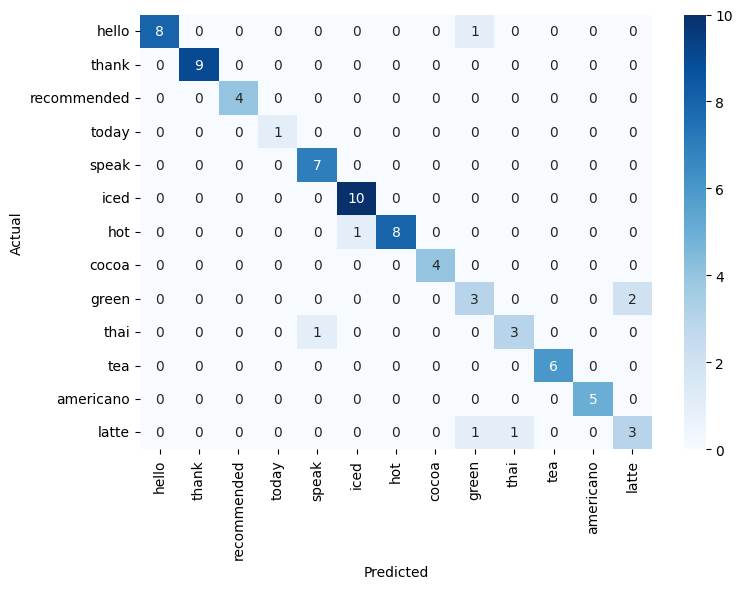

In [41]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# ===== ใช้ actions เป็น label =====
labels = actions.tolist()      # แปลง np.array → list

# ----- Confusion Matrix -----
cm = confusion_matrix(ytrue, yhat, labels=range(len(labels)))

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels,
            yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("")
plt.tight_layout()
plt.show()


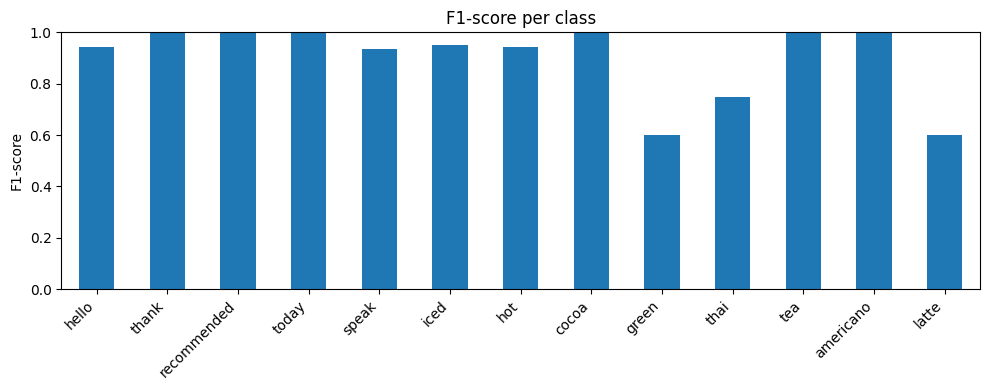

In [42]:
import pandas as pd
report = classification_report(ytrue, yhat, target_names=labels, output_dict=True)
df = pd.DataFrame(report).transpose().iloc[:-3, :]    # ตัด avg ออก

df[['f1-score']].plot(kind='bar', figsize=(10,4), legend=False)
plt.ylabel("F1-score")
plt.ylim(0,1)
plt.title("F1-score per class")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
report = classification_report(ytrue, yhat, target_names=labels, output_dict=True)
df = pd.DataFrame(report).transpose().iloc[:-3, :]    # ตัด avg ออก

df[['f1-score']].plot(kind='bar', figsize=(10,4), legend=False)
plt.ylabel("F1-score")
plt.ylim(0,1)
plt.title("F1-score per class")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

<h2>Test</h2>

In [ ]:
from scipy import stats

In [ ]:
colors = [
    (255, 99, 71),     # Tomato
    (135, 206, 235),   # Sky Blue
    (124, 252, 0),     # Lawn Green
    (255, 215, 0),     # Gold
    (186, 85, 211),    # Medium Orchid
    (60, 179, 113),    # Medium Sea Green
    (255, 140, 0),     # Dark Orange
    (30, 144, 255),    # Dodger Blue
    (220, 20, 60),     # Crimson
    (218, 165, 32),    # Goldenrod
    (255, 105, 180),   # Hot Pink
    (0, 191, 255),     # Deep Sky Blue
    (154, 205, 50),    # Yellow Green
    (123, 104, 238),   # Medium Slate Blue
    (255, 69, 0),      # Orange Red
    (0, 255, 255),     # Cyan
    (0, 250, 154),     # Medium Spring Green
    (255, 182, 193)    # Light Pink
]


In [ ]:

def prob_viz(res, actions, input_frame, colors):
    output_frame = input_frame.copy()
    for num, prob in enumerate(res):
        cv2.rectangle(output_frame, (0,60+num*40), (int(prob*100), 90+num*40), colors[num], -1)
        cv2.putText(output_frame, actions[num], (0, 85+num*40), cv2.FONT_HERSHEY_SIMPLEX, 1, (255,255,255), 2, cv2.LINE_AA)
        
    return output_frame

In [ ]:
plt.figure(figsize=(18,18))
plt.imshow(prob_viz(res, actions, image, colors))

In [ ]:
sequence.reverse()

In [ ]:
len(sequence)

In [ ]:
sequence[-30:]

In [ ]:
sequence = []
sentence = []
threshold = 0.8

cap = cv2.VideoCapture(0)
# Set mediapipe model 
with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
    while cap.isOpened():

        # Read feed
        ret, frame = cap.read()

        # Make detections
        image, results = mediapipe_detection(frame, holistic)
        print(results)
        
        # Draw landmarks
        draw_styled_landmarks(image, results)
        
        # 2. Prediction logic
        keypoints = extract_keypoints(results)
#         sequence.insert(0,keypoints)
#         sequence = sequence[:30]
        sequence.append(keypoints)
        sequence = sequence[-25:]
        
        if len(sequence) == 25:
            res = model.predict(np.expand_dims(sequence, axis=0))[0]
            print(actions[np.argmax(res)])
            
            
        #3. Viz logic
            if res[np.argmax(res)] > threshold:
                predictions_queue.append(actions[np.argmax(res)])
                
                if len(predictions_queue) > 3:
                    predictions_queue = predictions_queue[-3:]

                    if predictions_queue.count(predictions_queue[0]) == 3:
                        if len(sentence) == 0 or predictions_queue[0] != sentence[-1]:
                            sentence.append(predictions_queue[0])

            if len(sentence) > 5: 
                sentence = sentence[-5:]

            # Viz probabilities
            image = prob_viz(res, actions, image, colors)
            
        cv2.rectangle(image, (0,0), (640, 40), (245, 117, 16), -1)
        cv2.putText(image, ' '.join(sentence), (3,30), 
                       cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2, cv2.LINE_AA)
        
        # Show to screen
        cv2.imshow('OpenCV Feed', image)

        # Break gracefully
        if cv2.waitKey(10) & 0xFF == ord('q'):
            break
    cap.release()
    cv2.destroyAllWindows()

In [ ]:
cap.release()
cv2.destroyAllWindows()

In [14]:
# pip install mediapipe==0.10.14 opencv-python
import cv2, mediapipe as mp, numpy as np

# --------- config ---------
IMAGE_PATH = "IMG_9978.jpg"     # ใช้ภาพเดิมเพื่อ detect keypoints แต่จะไม่แสดงภาพคน
OUT_PATH   = "skeleton_only.png"
VIS_TH     = 0.5                # เกณฑ์ visibility ของ Pose
INCLUDE_HIPS = False            # เอาเอว(23,24) ไหม
BG = "transparent"              # "transparent" | "white" | "black"

# สี BGR
C_POSE  = (50, 220, 50)         # เขียว (pose)
C_LHAND = (255, 120, 30)        # ส้ม (มือซ้าย)
C_RHAND = (30, 180, 255)        # ฟ้า (มือขวา)

# ความหนาเส้นพื้นฐาน
BASE_TH_POSE  = 10
BASE_TH_HAND  = 10
DOT_RADIUS    = 14

mp_holistic = mp.solutions.holistic
POSE_CONN   = mp_holistic.POSE_CONNECTIONS
HAND_CONN   = mp_holistic.HAND_CONNECTIONS

# ---- เฉพาะท่อนบน ----
UPPER_BODY_IDX = set([0,1,2,3,4,5,6,7,8,9,10, 11,12,13,14,15,16, 17,18,19,20,21,22])
if INCLUDE_HIPS:
    UPPER_BODY_IDX |= {23,24}

def to_xy_px(landmarks, w, h):
    xs = np.array([lm.x for lm in landmarks.landmark], dtype=np.float32) * w
    ys = np.array([lm.y for lm in landmarks.landmark], dtype=np.float32) * h
    return np.stack([xs, ys], axis=1)

# ====== ปรับ "ความหนาเฉพาะส่วน" ที่อยากเน้น ======
# ตัวอย่าง: เน้นหัวไหล่-ศอก-ข้อมือหนาขึ้น
POSE_THICK_OVERRIDE = {
    # (i,j): thickness
    (11,13): 4, (13,15): 4,           # แขนซ้าย: ไหล่-ศอก, ศอก-ข้อมือ
    (12,14): 4, (14,16): 4,           # แขนขวา
    (15,17): 3, (17,19): 3, (19,21): 3,  # นิ้วโป้ง/ก้อย reference แขนซ้าย (บางโมเดล)
    (16,18): 3, (18,20): 3, (20,22): 3,  # แขนขวา
}
HAND_THICK_OVERRIDE = {
    # เน้นโครงมือให้หนา (ใส่บางเส้น หรือจะไม่ใส่ก็ได้)
    # ตัวอย่าง: โหนกมือ (0) ไปนิ้วหัวแม่มือ 1-2-3-4
    (0,1): 3, (1,2): 3, (2,3): 3, (3,4): 3,
}

def line_thickness(i, j, base_th, override_map):
    return override_map.get((i,j), override_map.get((j,i), base_th))

def make_canvas(h, w, bg="transparent"):
    if bg == "transparent":
        canvas = np.zeros((h, w, 4), dtype=np.uint8)  # BGRA
    else:
        color = {"white": (255,255,255,255), "black": (0,0,0,255)}.get(bg, (255,255,255,255))
        canvas = np.full((h, w, 4), color, dtype=np.uint8)
    return canvas

def draw_line(canvas, p1, p2, color_bgr, th):
    # รองรับ BGRA: แปลงสี BGR -> BGRA (ทึบ)
    color = (*color_bgr, 255)
    cv2.line(canvas, p1, p2, color, th, cv2.LINE_AA)

def draw_dot(canvas, p, color_bgr, r):
    color = (*color_bgr, 255)
    cv2.circle(canvas, p, r, color, -1, cv2.LINE_AA)

def main():
    bgr = cv2.imread(IMAGE_PATH)
    if bgr is None: raise FileNotFoundError(IMAGE_PATH)
    h, w = bgr.shape[:2]

    with mp_holistic.Holistic(
        static_image_mode=True, model_complexity=2,
        enable_segmentation=False, refine_face_landmarks=False
    ) as holo:
        res = holo.process(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB))

    canvas = make_canvas(h, w, BG)  # พื้นหลังว่าง

    # ---------- Pose (upper only + visibility) ----------
    if res.pose_landmarks:
        pose_xy = to_xy_px(res.pose_landmarks, w, h)
        vis = np.array([lm.visibility for lm in res.pose_landmarks.landmark], dtype=np.float32)
        mask = (vis >= VIS_TH)
        # ปิดส่วนล่างลำตัว
        for i in range(len(mask)):
            if i not in UPPER_BODY_IDX: mask[i] = False

        # กรอง connections เหลือเฉพาะท่อนบน
        pose_conn_upper = [(i,j) for (i,j) in POSE_CONN if i in UPPER_BODY_IDX and j in UPPER_BODY_IDX]

        # เส้น
        for (i,j) in pose_conn_upper:
            if not (mask[i] and mask[j]): continue
            p1 = tuple(np.round(pose_xy[i]).astype(int))
            p2 = tuple(np.round(pose_xy[j]).astype(int))
            th = line_thickness(i, j, BASE_TH_POSE, POSE_THICK_OVERRIDE)
            draw_line(canvas, p1, p2, C_POSE, th)

        # จุด
        keep = [i for i in range(len(pose_xy)) if mask[i]]
        for i in keep:
            p = tuple(np.round(pose_xy[i]).astype(int))
            draw_dot(canvas, p, C_POSE, DOT_RADIUS)

    # ---------- Left hand ----------
    if res.left_hand_landmarks:
        l_xy = to_xy_px(res.left_hand_landmarks, w, h)
        for (i,j) in HAND_CONN:
            p1 = tuple(np.round(l_xy[i]).astype(int))
            p2 = tuple(np.round(l_xy[j]).astype(int))
            th = line_thickness(i, j, BASE_TH_HAND, HAND_THICK_OVERRIDE)
            draw_line(canvas, p1, p2, C_LHAND, th)
        for i in range(len(l_xy)):
            draw_dot(canvas, tuple(np.round(l_xy[i]).astype(int)), C_LHAND, DOT_RADIUS)

    # ---------- Right hand ----------
    if res.right_hand_landmarks:
        r_xy = to_xy_px(res.right_hand_landmarks, w, h)
        for (i,j) in HAND_CONN:
            p1 = tuple(np.round(r_xy[i]).astype(int))
            p2 = tuple(np.round(r_xy[j]).astype(int))
            th = line_thickness(i, j, BASE_TH_HAND, HAND_THICK_OVERRIDE)
            draw_line(canvas, p1, p2, C_RHAND, th)
        for i in range(len(r_xy)):
            draw_dot(canvas, tuple(np.round(r_xy[i]).astype(int)), C_RHAND, DOT_RADIUS)

    # บันทึก (PNG โปร่งใสได้)
    cv2.imwrite(OUT_PATH, canvas)
    print(f"saved -> {OUT_PATH}")

if __name__ == "__main__":
    main()


I0000 00:00:1760536069.983626  103939 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1760536069.999130  119432 gl_context.cc:369] GL version: 3.0 (OpenGL ES 3.0 Mesa 24.2.8-1ubuntu1~24.04.1), renderer: D3D12 (Intel(R) Iris(R) Xe Graphics)
W0000 00:00:1760536070.143405  119426 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1760536070.297611  119428 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1760536070.300517  119430 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1760536070.304558  119424 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensor

saved -> skeleton_only.png
